In [135]:
import pandas as pd
import numpy as np
from itertools import combinations
import krippendorff
from collections import Counter
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [136]:
df_first = pd.read_csv('../data/all_annotations_30_first.csv')
df_repeated = pd.read_csv('../data/all_annotations_30_repeated.csv')

df_first['annotator_group'] = df_first['annotator'] // 5
df_repeated['annotator_group'] = df_repeated['annotator'] // 5

# Techniques

In [137]:
def parse_techniques(text):
    if pd.isna(text):
        return set()
    return set(t.strip() for t in str(text).split('\n') if t.strip())

def recall_vs_gold(pred_set, gold_set):
    if not gold_set:
        return 1.0
    return len(pred_set & gold_set) / len(gold_set)

def precision_vs_gold(pred_set, gold_set):
    if not pred_set:
        return 1.0 if not gold_set else 0.0
    return len(pred_set & gold_set) / len(pred_set)

def f1_vs_gold(pred_set, gold_set):
    p = precision_vs_gold(pred_set, gold_set)
    r = recall_vs_gold(pred_set, gold_set)
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)

## Majority Gold
Gold = techniques selected by more than 50% for each text

In [138]:
def compute_majority_gold_techniques(df, threshold=0.5):
    gold = {}
    for example_id in df['id'].unique():
        technique_counts = Counter()
        n_annotators = 0
        for text in df[df['id'] == example_id]['question_2_techniques'].dropna():
            technique_counts.update(parse_techniques(text))
            n_annotators += 1
        gold[example_id] = set(t for t, c in technique_counts.items() if c / n_annotators >= threshold)
    return gold

In [139]:
majority_gold_first = compute_majority_gold_techniques(df_first)
majority_gold_repeated = compute_majority_gold_techniques(df_repeated)

df_first['techniques_set'] = df_first['question_2_techniques'].apply(parse_techniques)
df_repeated['techniques_set'] = df_repeated['question_2_techniques'].apply(parse_techniques)

df_first['majority_gold'] = df_first['id'].map(majority_gold_first)
df_repeated['majority_gold'] = df_repeated['id'].map(majority_gold_repeated)

df_first['majority_recall'] = df_first.apply(lambda r: recall_vs_gold(r['techniques_set'], r['majority_gold']), axis=1)
df_first['majority_precision'] = df_first.apply(lambda r: precision_vs_gold(r['techniques_set'], r['majority_gold']), axis=1)
df_first['majority_f1'] = df_first.apply(lambda r: f1_vs_gold(r['techniques_set'], r['majority_gold']), axis=1)

df_repeated['majority_recall'] = df_repeated.apply(lambda r: recall_vs_gold(r['techniques_set'], r['majority_gold']), axis=1)
df_repeated['majority_precision'] = df_repeated.apply(lambda r: precision_vs_gold(r['techniques_set'], r['majority_gold']), axis=1)
df_repeated['majority_f1'] = df_repeated.apply(lambda r: f1_vs_gold(r['techniques_set'], r['majority_gold']), axis=1)

In [140]:
majority_results = pd.DataFrame({
    'dataset': ['first', 'repeated'],
    'mean_recall': [df_first['majority_recall'].mean(), df_repeated['majority_recall'].mean()],
    'mean_precision': [df_first['majority_precision'].mean(), df_repeated['majority_precision'].mean()],
    'mean_f1': [df_first['majority_f1'].mean(), df_repeated['majority_f1'].mean()]
})
majority_results

,dataset,mean_recall,mean_precision,mean_f1
0,first,0.744348,0.613894,0.629827
1,repeated,0.749444,0.629101,0.640685


## Union Gold
Gold = All techniques selected by any annotator

In [141]:
def compute_union_gold(df):
    gold = {}
    for example_id in df['id'].unique():
        all_techniques = set()
        for text in df[df['id'] == example_id]['question_2_techniques'].dropna():
            all_techniques.update(parse_techniques(text))
        gold[example_id] = all_techniques
    return gold

In [142]:
union_gold_first = compute_union_gold(df_first)
union_gold_repeated = compute_union_gold(df_repeated)

df_first['union_gold'] = df_first['id'].map(union_gold_first)
df_repeated['union_gold'] = df_repeated['id'].map(union_gold_repeated)

df_first['union_recall'] = df_first.apply(lambda r: recall_vs_gold(r['techniques_set'], r['union_gold']), axis=1)
df_first['union_precision'] = df_first.apply(lambda r: precision_vs_gold(r['techniques_set'], r['union_gold']), axis=1)
df_first['union_f1'] = df_first.apply(lambda r: f1_vs_gold(r['techniques_set'], r['union_gold']), axis=1)

df_repeated['union_recall'] = df_repeated.apply(lambda r: recall_vs_gold(r['techniques_set'], r['union_gold']), axis=1)
df_repeated['union_precision'] = df_repeated.apply(lambda r: precision_vs_gold(r['techniques_set'], r['union_gold']), axis=1)
df_repeated['union_f1'] = df_repeated.apply(lambda r: f1_vs_gold(r['techniques_set'], r['union_gold']), axis=1)

In [143]:
union_results = pd.DataFrame({
    'dataset': ['first', 'repeated'],
    'mean_recall': [df_first['union_recall'].mean(), df_repeated['union_recall'].mean()],
    'mean_precision': [df_first['union_precision'].mean(), df_repeated['union_precision'].mean()],
    'mean_f1': [df_first['union_f1'].mean(), df_repeated['union_f1'].mean()]
})
union_results

,dataset,mean_recall,mean_precision,mean_f1
0,first,0.432506,0.920000,0.556419
1,repeated,0.433475,0.930574,0.560674


In [144]:
techniques_summary = pd.concat([
    majority_results.assign(approach='Majority Gold'),
    union_results.assign(approach='Union Gold')
])[['approach', 'dataset', 'mean_recall', 'mean_precision', 'mean_f1']]
techniques_summary.columns = ['approach', 'dataset', 'recall', 'precision', 'f1']
techniques_summary

,approach,dataset,recall,precision,f1
0,Majority Gold,first,0.744348,0.613894,0.629827
1,Majority Gold,repeated,0.749444,0.629101,0.640685
0,Union Gold,first,0.432506,0.920000,0.556419
1,Union Gold,repeated,0.433475,0.930574,0.560674


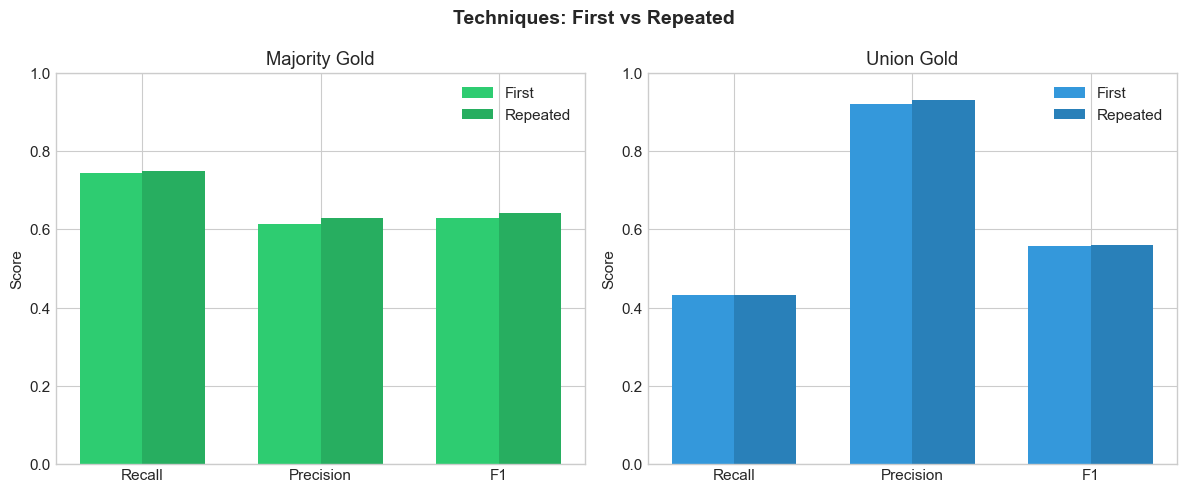

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(3)
width = 0.35

metrics = ['recall', 'precision', 'f1']
maj_first = [df_first['majority_recall'].mean(), df_first['majority_precision'].mean(), df_first['majority_f1'].mean()]
maj_repeated = [df_repeated['majority_recall'].mean(), df_repeated['majority_precision'].mean(), df_repeated['majority_f1'].mean()]

axes[0].bar(x - width/2, maj_first, width, label='First', color='#2ecc71')
axes[0].bar(x + width/2, maj_repeated, width, label='Repeated', color='#27ae60')
axes[0].set_ylabel('Score')
axes[0].set_title('Majority Gold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Recall', 'Precision', 'F1'])
axes[0].legend()
axes[0].set_ylim(0, 1)

uni_first = [df_first['union_recall'].mean(), df_first['union_precision'].mean(), df_first['union_f1'].mean()]
uni_repeated = [df_repeated['union_recall'].mean(), df_repeated['union_precision'].mean(), df_repeated['union_f1'].mean()]

axes[1].bar(x - width/2, uni_first, width, label='First', color='#3498db')
axes[1].bar(x + width/2, uni_repeated, width, label='Repeated', color='#2980b9')
axes[1].set_ylabel('Score')
axes[1].set_title('Union Gold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Recall', 'Precision', 'F1'])
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.suptitle('Techniques: First vs Repeated', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Krippendorff's Alpha at Technique Level
Agreement computed for each technique as a binary variable (present/absent) across all texts and annotators

In [146]:
def get_all_techniques(df):
    all_techs = set()
    for text in df['question_2_techniques'].dropna():
        all_techs.update(parse_techniques(text))
    return sorted(all_techs)

def build_technique_matrix(df, technique):
    def has_technique(text):
        if pd.isna(text):
            return np.nan
        return 1 if technique in parse_techniques(text) else 0
    
    df_copy = df.copy()
    df_copy['has_tech'] = df_copy['question_2_techniques'].apply(has_technique)
    
    pivot = df_copy.pivot_table(
        index='id', 
        columns='annotator_group', 
        values='has_tech', 
        aggfunc='first'
    )
    return pivot.values.T

def krippendorff_technique(df, technique):
    matrix = build_technique_matrix(df, technique)
    valid_values = matrix[~np.isnan(matrix)]
    if len(np.unique(valid_values)) < 2:
        return np.nan
    try:
        return krippendorff.alpha(reliability_data=matrix, level_of_measurement='nominal')
    except:
        return np.nan

In [147]:
def bootstrap_krippendorff_ci(df, technique, n_bootstrap=1000, ci=0.95):
    matrix = build_technique_matrix(df, technique)
    n_items = matrix.shape[1]
    
    boot_alphas = []
    for _ in range(n_bootstrap):
        indices = np.random.choice(n_items, size=n_items, replace=True)
        boot_matrix = matrix[:, indices]
        
        valid_values = boot_matrix[~np.isnan(boot_matrix)]
        if len(np.unique(valid_values)) < 2:
            continue
        
        try:
            alpha = krippendorff.alpha(reliability_data=boot_matrix, level_of_measurement='nominal')
            boot_alphas.append(alpha)
        except:
            continue
    
    if len(boot_alphas) < 100:
        return np.nan, np.nan, np.nan
    
    boot_alphas = np.array(boot_alphas)
    alpha_low = np.percentile(boot_alphas, (1 - ci) / 2 * 100)
    alpha_high = np.percentile(boot_alphas, (1 + ci) / 2 * 100)
    se = np.std(boot_alphas)
    
    return alpha_low, alpha_high, se


def bootstrap_alpha_difference_test(df1, df2, technique, n_bootstrap=1000):
    matrix1 = build_technique_matrix(df1, technique)
    matrix2 = build_technique_matrix(df2, technique)
    
    try:
        alpha1 = krippendorff.alpha(reliability_data=matrix1, level_of_measurement='nominal')
        alpha2 = krippendorff.alpha(reliability_data=matrix2, level_of_measurement='nominal')
        observed_diff = alpha2 - alpha1
    except:
        return np.nan, np.nan, np.nan
    
    if np.isnan(alpha1) or np.isnan(alpha2):
        return np.nan, np.nan, np.nan
    
    n_items1 = matrix1.shape[1]
    n_items2 = matrix2.shape[1]
    
    boot_diffs = []
    for _ in range(n_bootstrap):
        idx1 = np.random.choice(n_items1, size=n_items1, replace=True)
        idx2 = np.random.choice(n_items2, size=n_items2, replace=True)
        
        boot_matrix1 = matrix1[:, idx1]
        boot_matrix2 = matrix2[:, idx2]
        
        try:
            a1 = krippendorff.alpha(reliability_data=boot_matrix1, level_of_measurement='nominal')
            a2 = krippendorff.alpha(reliability_data=boot_matrix2, level_of_measurement='nominal')
            if not np.isnan(a1) and not np.isnan(a2):
                boot_diffs.append(a2 - a1)
        except:
            continue
    
    if len(boot_diffs) < 100:
        return observed_diff, np.nan, np.nan
    
    boot_diffs = np.array(boot_diffs)
    se_diff = np.std(boot_diffs)
    centered_diffs = boot_diffs - np.mean(boot_diffs)
    p_value = np.mean(np.abs(centered_diffs) >= np.abs(observed_diff))
    
    return observed_diff, se_diff, p_value

In [148]:
all_techniques_first = get_all_techniques(df_first)
all_techniques_repeated = get_all_techniques(df_repeated)
all_techniques = sorted(set(all_techniques_first) | set(all_techniques_repeated))

print(f"Total unique techniques: {len(all_techniques)}")
print(f"In first dataset: {len(all_techniques_first)}")
print(f"In repeated dataset: {len(all_techniques_repeated)}")

Total unique techniques: 20
In first dataset: 20
In repeated dataset: 20


In [149]:
np.random.seed(42)

technique_results = []
for tech in all_techniques:
    alpha_first = krippendorff_technique(df_first, tech)
    alpha_repeated = krippendorff_technique(df_repeated, tech)
    
    ci_low_first, ci_high_first, se_first = bootstrap_krippendorff_ci(df_first, tech, n_bootstrap=500)
    ci_low_rep, ci_high_rep, se_rep = bootstrap_krippendorff_ci(df_repeated, tech, n_bootstrap=500)
    
    diff, se_diff, p_value = bootstrap_alpha_difference_test(df_first, df_repeated, tech, n_bootstrap=500)
    
    count_first = sum(tech in parse_techniques(t) for t in df_first['question_2_techniques'].dropna())
    count_repeated = sum(tech in parse_techniques(t) for t in df_repeated['question_2_techniques'].dropna())
    
    technique_results.append({
        'technique': tech,
        'alpha_first': alpha_first,
        'alpha_repeated': alpha_repeated,
        'ci_low_first': ci_low_first,
        'ci_high_first': ci_high_first,
        'ci_low_repeated': ci_low_rep,
        'ci_high_repeated': ci_high_rep,
        'difference': diff,
        'se_diff': se_diff,
        'p_value': p_value,
        'significant': p_value < 0.05 if not np.isnan(p_value) else False,
        'count_first': count_first,
        'count_repeated': count_repeated
    })

df_tech_alpha = pd.DataFrame(technique_results)
print(f"Computed agreement for {len(df_tech_alpha)} techniques")

Computed agreement for 20 techniques


In [150]:
display_cols = ['technique', 'alpha_first', 'alpha_repeated', 'difference', 'p_value', 'significant', 'count_first', 'count_repeated']
df_tech_display = df_tech_alpha[display_cols].copy()
df_tech_display = df_tech_display.sort_values('difference', ascending=False)

df_tech_display['alpha_first'] = df_tech_display['alpha_first'].round(3)
df_tech_display['alpha_repeated'] = df_tech_display['alpha_repeated'].round(3)
df_tech_display['difference'] = df_tech_display['difference'].round(3)
df_tech_display['p_value'] = df_tech_display['p_value'].round(3)

pd.set_option('display.max_rows', None)
df_tech_display

,technique,alpha_first,alpha_repeated,difference,p_value,significant,count_first,count_repeated
5,Humor,0.308,0.528,0.220,0.304,False,32,31
0,Autorytet,0.281,0.415,0.134,0.228,False,89,78
3,Efekt „wszyscy to wiedzą”,0.410,0.507,0.097,0.276,False,120,123
1,"Dać, aby wziąć",0.431,0.523,0.092,0.452,False,66,74
11,Okazywanie wdzięczności,0.403,0.483,0.080,0.464,False,62,60
7,Jesteśmy wyjątkowi,0.343,0.410,0.067,0.450,False,134,125
6,Huśtawka emocjonalna,0.138,0.163,0.025,0.846,False,44,39
13,Podobieństwa,0.366,0.386,0.020,0.886,False,69,64
19,U nas tak się robi,0.301,0.317,0.016,0.836,False,85,103
14,Przewidywanie żalu,0.447,0.460,0.014,0.870,False,153,143


In [151]:
valid_alphas = df_tech_alpha.dropna(subset=['alpha_first', 'alpha_repeated'])

summary_stats = pd.DataFrame({
    'Metric': ['Mean α', 'Median α', 'Std α', 'Min α', 'Max α', 'N techniques'],
    'First': [
        valid_alphas['alpha_first'].mean(),
        valid_alphas['alpha_first'].median(),
        valid_alphas['alpha_first'].std(),
        valid_alphas['alpha_first'].min(),
        valid_alphas['alpha_first'].max(),
        len(valid_alphas)
    ],
    'Repeated': [
        valid_alphas['alpha_repeated'].mean(),
        valid_alphas['alpha_repeated'].median(),
        valid_alphas['alpha_repeated'].std(),
        valid_alphas['alpha_repeated'].min(),
        valid_alphas['alpha_repeated'].max(),
        len(valid_alphas)
    ]
}).round(3)

print("Technique-Level Krippendorff's Alpha Summary:")
summary_stats

Technique-Level Krippendorff's Alpha Summary:


,Metric,First,Repeated
0,Mean α,0.367,0.389
1,Median α,0.369,0.413
2,Std α,0.160,0.170
3,Min α,0.065,0.069
4,Max α,0.686,0.688
5,N techniques,20.000,20.000


In [152]:
valid_pairs = df_tech_alpha.dropna(subset=['alpha_first', 'alpha_repeated'])

if len(valid_pairs) >= 5:
    t_stat, t_pval = stats.ttest_rel(valid_pairs['alpha_first'], valid_pairs['alpha_repeated'])
    w_stat, w_pval = stats.wilcoxon(valid_pairs['alpha_first'], valid_pairs['alpha_repeated'])
    
    print("Overall change in technique-level agreement (First → Repeated):")
    print(f"  Mean α change: {valid_pairs['difference'].mean():.3f}")
    print(f"  Paired t-test: t={t_stat:.3f}, p={t_pval:.4f}")
    print(f"  Wilcoxon signed-rank: W={w_stat:.1f}, p={w_pval:.4f}")
    print(f"  N significant individual techniques (p<.05): {valid_pairs['significant'].sum()} / {len(valid_pairs)}")
else:
    print("Not enough valid technique pairs for statistical testing")

Overall change in technique-level agreement (First → Repeated):
  Mean α change: 0.022
  Paired t-test: t=-1.295, p=0.2110
  Wilcoxon signed-rank: W=74.0, p=0.2611
  N significant individual techniques (p<.05): 0 / 20


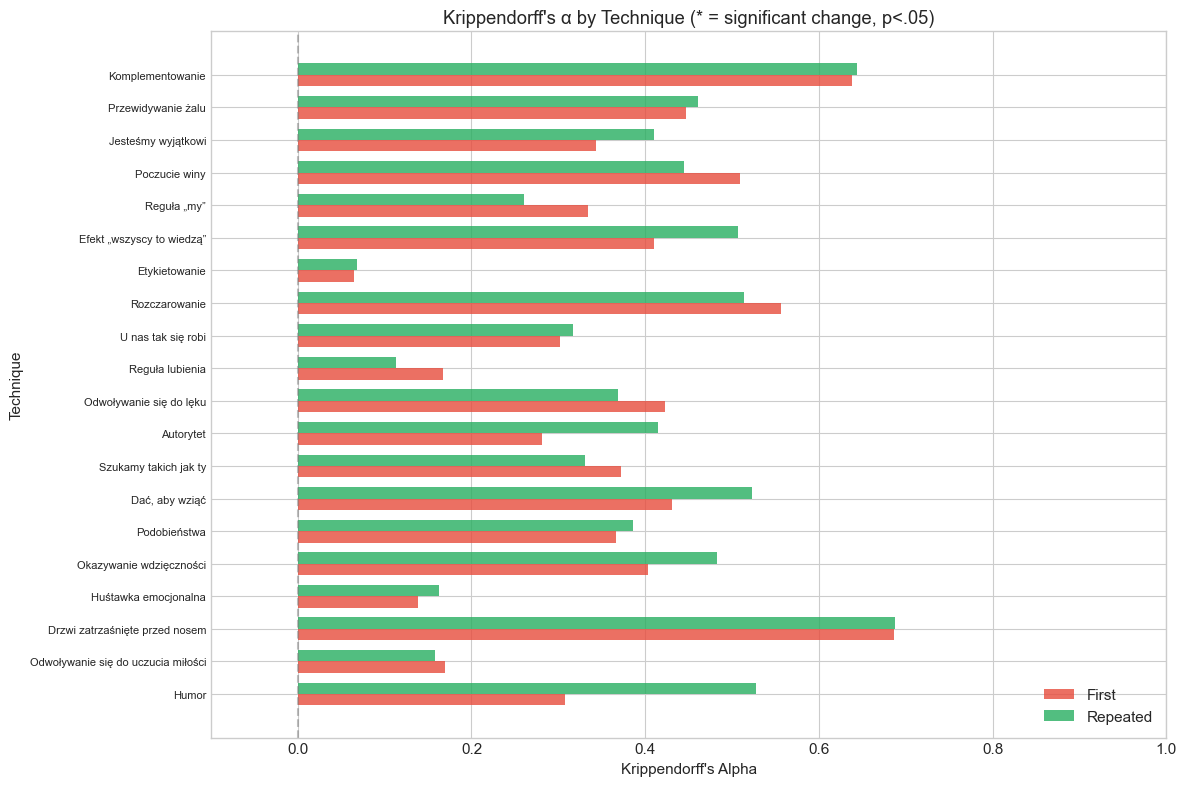

In [153]:
valid_tech = df_tech_alpha.dropna(subset=['alpha_first', 'alpha_repeated']).copy()
valid_tech['total_count'] = valid_tech['count_first'] + valid_tech['count_repeated']
valid_tech = valid_tech.sort_values('total_count', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(8, len(valid_tech) * 0.35)))

y = np.arange(len(valid_tech))
height = 0.35

bars1 = ax.barh(y - height/2, valid_tech['alpha_first'], height, label='First', color='#e74c3c', alpha=0.8)
bars2 = ax.barh(y + height/2, valid_tech['alpha_repeated'], height, label='Repeated', color='#27ae60', alpha=0.8)

for i, (_, row) in enumerate(valid_tech.iterrows()):
    if row['significant']:
        ax.annotate('*', xy=(max(row['alpha_first'], row['alpha_repeated']) + 0.02, i),
                    fontsize=12, fontweight='bold', color='black')

ax.set_xlabel("Krippendorff's Alpha")
ax.set_ylabel('Technique')
ax.set_yticks(y)
ax.set_yticklabels([t[:40] + '...' if len(t) > 40 else t for t in valid_tech['technique']], fontsize=8)
ax.legend(loc='lower right')
ax.set_xlim(-0.1, 1.0)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title("Krippendorff's α by Technique (* = significant change, p<.05)")

plt.tight_layout()
plt.show()

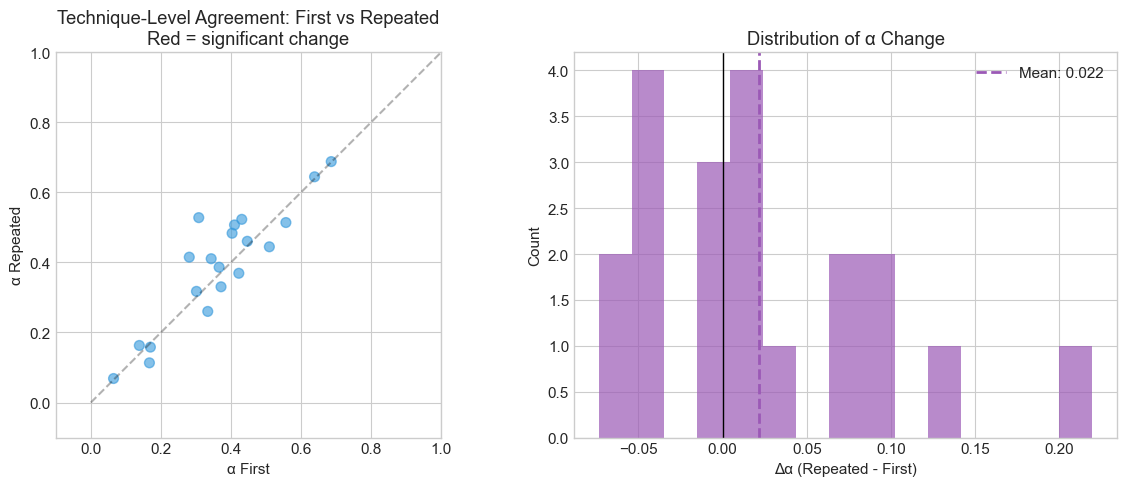

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter = axes[0].scatter(valid_tech['alpha_first'], valid_tech['alpha_repeated'], 
                          c=valid_tech['significant'].map({True: '#e74c3c', False: '#3498db'}),
                          alpha=0.6, s=50)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='No change')
axes[0].set_xlabel("α First")
axes[0].set_ylabel("α Repeated")
axes[0].set_title("Technique-Level Agreement: First vs Repeated\nRed = significant change")
axes[0].set_xlim(-0.1, 1.0)
axes[0].set_ylim(-0.1, 1.0)
axes[0].set_aspect('equal')

diffs = valid_tech['difference'].dropna()
axes[1].hist(diffs, bins=15, alpha=0.7, color='#9b59b6')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].axvline(diffs.mean(), color='#9b59b6', linestyle='--', linewidth=2, label=f'Mean: {diffs.mean():.3f}')
axes[1].set_xlabel('Δα (Repeated - First)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of α Change')
axes[1].legend()

plt.tight_layout()
plt.show()

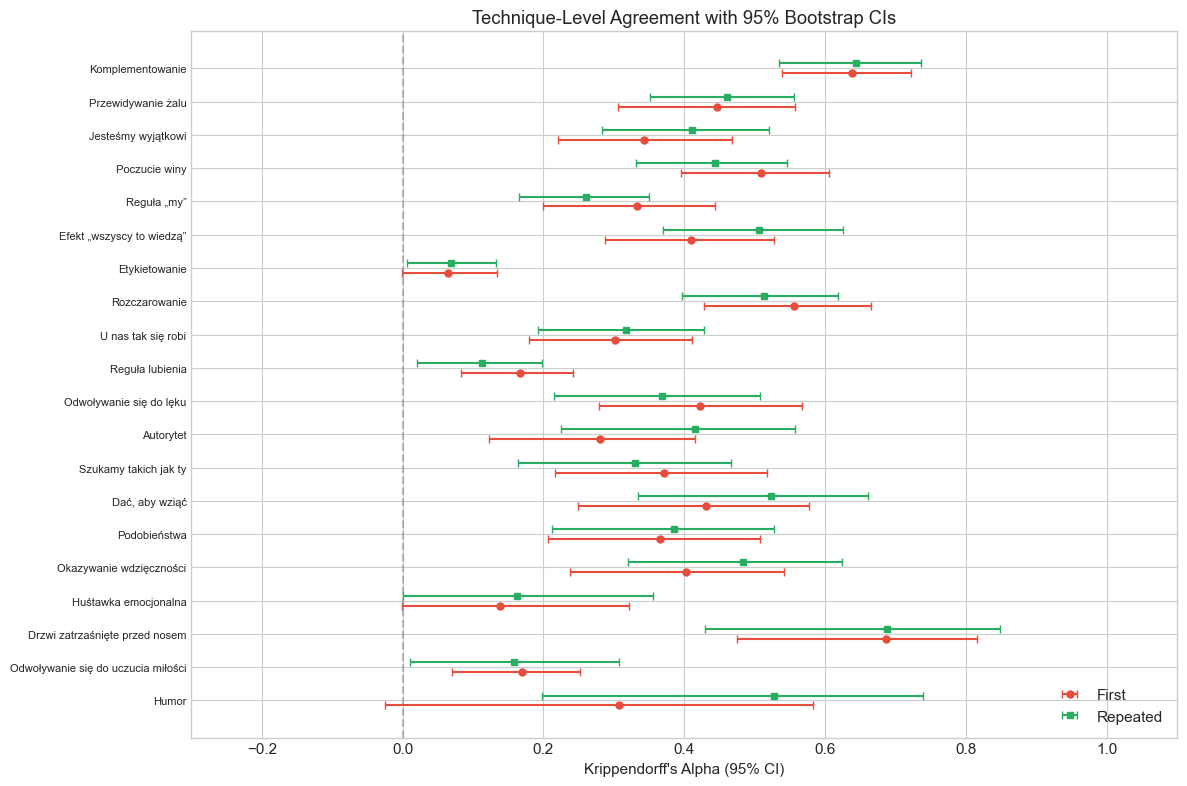

In [155]:
valid_tech_sorted = valid_tech.sort_values('total_count', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(8, len(valid_tech_sorted) * 0.4)))

y_positions = np.arange(len(valid_tech_sorted))
offset = 0.15

for i, (_, row) in enumerate(valid_tech_sorted.iterrows()):
    if not np.isnan(row['ci_low_first']) and not np.isnan(row['ci_high_first']):
        ax.errorbar(row['alpha_first'], i - offset, 
                   xerr=[[row['alpha_first'] - row['ci_low_first']], 
                         [row['ci_high_first'] - row['alpha_first']]],
                   fmt='o', color='#e74c3c', capsize=3, markersize=5, label='First' if i == 0 else '')

for i, (_, row) in enumerate(valid_tech_sorted.iterrows()):
    if not np.isnan(row['ci_low_repeated']) and not np.isnan(row['ci_high_repeated']):
        ax.errorbar(row['alpha_repeated'], i + offset,
                   xerr=[[row['alpha_repeated'] - row['ci_low_repeated']], 
                         [row['ci_high_repeated'] - row['alpha_repeated']]],
                   fmt='s', color='#27ae60', capsize=3, markersize=5, label='Repeated' if i == 0 else '')

ax.set_yticks(y_positions)
ax.set_yticklabels([t[:40] + '...' if len(t) > 40 else t for t in valid_tech_sorted['technique']], fontsize=8)
ax.set_xlabel("Krippendorff's Alpha (95% CI)")
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlim(-0.3, 1.1)
ax.legend(loc='lower right')
ax.set_title("Technique-Level Agreement with 95% Bootstrap CIs")

plt.tight_layout()
plt.show()

# Other questions

In [156]:
ORDINAL_MAPPINGS = {
    'question_1_influence_presence': {
        'Brak wpływu': 0, 'Słabo widoczny': 1, 'Umiarkowanie widoczny': 2,
        'Dobrze widoczny': 3, 'Jednoznaczny': 4, 'Trudno ocenić': np.nan
    },
    'question_3_intention_clarity': {
        'Brak widocznej intencji': 0, 'Intencja słabo widoczna': 1,
        'Intencja umiarkowanie widoczna': 2, 'Intencja dobrze widoczna': 3,
        'Intencja otwarcie wyrażona': 4, 'Trudno ocenić': np.nan
    },
    'question_6_consequences_severity': {
        'Minimalne/brak': 0, 'Niewielkie': 1, 'Umiarkowane': 2,
        'Znaczne': 3, 'Poważne': 4, 'Trudno ocenić': np.nan
    },
    'question_7_submission': {
        'Nie uległa': 0, 'Uległa': 1, 'Trudno ocenić': np.nan
    },
    'question_8_resistance': {
        'Brak oporu': 0, 'Niewielki opór': 1, 'Zauważalny opór': 2,
        'Średni opór': 3, 'Bardzo duży opór': 4, 'Trudno ocenić': np.nan
    },
    'question_10_certainty': {
        'Zupełny brak pewności': 0, 'Niska pewność': 1,
        'Umiarkowana pewność': 2, 'Wysoka pewność': 3, 'Całkowita pewność': 4
    }
}

def get_valid_categories(mapping):
    return [k for k, v in mapping.items() if not (isinstance(v, float) and np.isnan(v))]

def get_scale_length(mapping):
    valid_vals = [v for v in mapping.values() if not (isinstance(v, float) and np.isnan(v))]
    return len(valid_vals)

## Text-Level Agreement
Agreement computed among the 5 annotators (one from each group) who rated each text

In [157]:
def fleiss_kappa_text_level(df, question, mapping):
    valid_cats = get_valid_categories(mapping)
    df_filtered = df[df[question].isin(valid_cats)].copy()
    
    pivot = df_filtered.pivot_table(index='id', columns='annotator_group', values=question, aggfunc='first')
    n_raters = pivot.notna().sum(axis=1)
    
    category_counts = pd.DataFrame(index=pivot.index, columns=valid_cats)
    for cat in valid_cats:
        category_counts[cat] = (pivot == cat).sum(axis=1)
    
    category_counts = category_counts.fillna(0)
    n = n_raters.values.reshape(-1, 1)
    
    valid_rows = n.flatten() > 1
    if valid_rows.sum() == 0:
        return np.nan
    
    P_i = (category_counts.values[valid_rows] ** 2).sum(axis=1) - n[valid_rows].flatten()
    P_i = P_i / (n[valid_rows].flatten() * (n[valid_rows].flatten() - 1))
    P_i = np.nan_to_num(P_i, nan=0)
    P_bar = np.mean(P_i)
    
    p_j = category_counts.loc[valid_rows].sum(axis=0) / category_counts.loc[valid_rows].sum().sum()
    P_e = (p_j ** 2).sum()
    
    return (P_bar - P_e) / (1 - P_e) if P_e < 1 else 0

def krippendorff_nominal_text_level(df, question, mapping):
    valid_cats = get_valid_categories(mapping)
    df_filtered = df[df[question].isin(valid_cats)].copy()
    
    pivot = df_filtered.pivot_table(index='id', columns='annotator_group', values=question, aggfunc='first')
    cat_to_num = {cat: i for i, cat in enumerate(valid_cats)}
    data = pivot.map(lambda x: cat_to_num.get(x, np.nan) if pd.notna(x) else np.nan).values.T
    return krippendorff.alpha(reliability_data=data, level_of_measurement='nominal')

def krippendorff_ordinal_text_level(df, question, mapping):
    valid_mapping = {k: v for k, v in mapping.items() if not (isinstance(v, float) and np.isnan(v))}
    df_filtered = df[df[question].isin(valid_mapping.keys())].copy()
    
    pivot = df_filtered.pivot_table(index='id', columns='annotator_group', values=question, aggfunc='first')
    data = pivot.map(lambda x: valid_mapping.get(x, np.nan) if pd.notna(x) else np.nan).values.T
    return krippendorff.alpha(reliability_data=data, level_of_measurement='ordinal')

## Exact Match
All disagreements treated equally - 1 vs 2 same as 1 vs 5

In [158]:
nominal_results = []
for question, mapping in ORDINAL_MAPPINGS.items():
    nominal_results.append({
        'question': question.replace('question_', 'Q'),
        'fleiss_first': fleiss_kappa_text_level(df_first, question, mapping),
        'fleiss_repeated': fleiss_kappa_text_level(df_repeated, question, mapping),
        'kripp_first': krippendorff_nominal_text_level(df_first, question, mapping),
        'kripp_repeated': krippendorff_nominal_text_level(df_repeated, question, mapping)
    })

df_nominal = pd.DataFrame(nominal_results)
df_nominal['fleiss_change'] = df_nominal['fleiss_repeated'] - df_nominal['fleiss_first']
df_nominal['kripp_change'] = df_nominal['kripp_repeated'] - df_nominal['kripp_first']
df_nominal

,question,fleiss_first,fleiss_repeated,kripp_first,kripp_repeated,fleiss_change,kripp_change
0,Q1_influence_presence,0.137061,0.091272,0.139444,0.092922,-0.045789,-0.046521
1,Q3_intention_clarity,0.098957,0.118431,0.114006,0.118708,0.019474,0.004702
2,Q6_consequences_severity,0.083216,0.017833,0.089843,0.030844,-0.065384,-0.058999
3,Q7_submission,0.819614,0.825081,0.862975,0.849294,0.005467,-0.013682
4,Q8_resistance,0.349929,0.316524,0.332317,0.312109,-0.033405,-0.020208
5,Q10_certainty,0.039099,0.027118,0.045463,0.031452,-0.011981,-0.014011


## Distance-Weighted
Disagreements weighted by distance - 1 vs 5 is worse than 4 vs 5

In [159]:
def mean_absolute_distance_text_level(df, question, mapping):
    valid_mapping = {k: v for k, v in mapping.items() if not (isinstance(v, float) and np.isnan(v))}
    df_filtered = df[df[question].isin(valid_mapping.keys())].copy()
    
    pivot = df_filtered.pivot_table(index='id', columns='annotator_group', values=question, aggfunc='first')
    
    distances = []
    for idx in pivot.index:
        vals = [valid_mapping[v] for v in pivot.loc[idx].dropna() if v in valid_mapping]
        if len(vals) >= 2:
            for i, j in combinations(range(len(vals)), 2):
                distances.append(abs(vals[i] - vals[j]))
    
    return np.mean(distances) if distances else np.nan

def normalized_distance_text_level(df, question, mapping):
    mad = mean_absolute_distance_text_level(df, question, mapping)
    max_dist = get_scale_length(mapping) - 1
    return mad / max_dist if max_dist > 0 else 0

In [160]:
ordinal_results = []
for question, mapping in ORDINAL_MAPPINGS.items():
    ordinal_results.append({
        'question': question.replace('question_', 'Q'),
        'kripp_ord_first': krippendorff_ordinal_text_level(df_first, question, mapping),
        'kripp_ord_repeated': krippendorff_ordinal_text_level(df_repeated, question, mapping),
        'mad_first': mean_absolute_distance_text_level(df_first, question, mapping),
        'mad_repeated': mean_absolute_distance_text_level(df_repeated, question, mapping),
        'norm_dist_first': normalized_distance_text_level(df_first, question, mapping),
        'norm_dist_repeated': normalized_distance_text_level(df_repeated, question, mapping),
        'scale_length': get_scale_length(mapping)
    })

df_ordinal = pd.DataFrame(ordinal_results)
df_ordinal['kripp_ord_change'] = df_ordinal['kripp_ord_repeated'] - df_ordinal['kripp_ord_first']
df_ordinal['mad_change'] = df_ordinal['mad_repeated'] - df_ordinal['mad_first']
df_ordinal

,question,kripp_ord_first,kripp_ord_repeated,mad_first,mad_repeated,norm_dist_first,norm_dist_repeated,scale_length,kripp_ord_change,mad_change
0,Q1_influence_presence,0.429457,0.334912,0.878492,0.866120,0.219623,0.216530,5,-0.094545,-0.012371
1,Q3_intention_clarity,0.351988,0.298828,0.857820,0.779904,0.214455,0.194976,5,-0.053160,-0.077916
2,Q6_consequences_severity,0.234158,0.168805,0.911093,0.949690,0.227773,0.237423,5,-0.065352,0.038597
3,Q7_submission,0.862975,0.849294,0.042139,0.052548,0.042139,0.052548,2,-0.013682,0.010408
4,Q8_resistance,0.543286,0.547081,0.854730,0.844156,0.213682,0.211039,5,0.003795,-0.010574
5,Q10_certainty,0.103413,0.085728,0.680897,0.649038,0.170224,0.162260,5,-0.017684,-0.031859


## Comparison - weighted and non-weighted

In [161]:
comparison = df_nominal[['question', 'kripp_first', 'kripp_repeated', 'kripp_change']].merge(
    df_ordinal[['question', 'kripp_ord_first', 'kripp_ord_repeated', 'kripp_ord_change']],
    on='question'
)
comparison.columns = ['question', 'nominal_first', 'nominal_repeated', 'nominal_change', 
                      'ordinal_first', 'ordinal_repeated', 'ordinal_change']
comparison

,question,nominal_first,nominal_repeated,nominal_change,ordinal_first,ordinal_repeated,ordinal_change
0,Q1_influence_presence,0.139444,0.092922,-0.046521,0.429457,0.334912,-0.094545
1,Q3_intention_clarity,0.114006,0.118708,0.004702,0.351988,0.298828,-0.053160
2,Q6_consequences_severity,0.089843,0.030844,-0.058999,0.234158,0.168805,-0.065352
3,Q7_submission,0.862975,0.849294,-0.013682,0.862975,0.849294,-0.013682
4,Q8_resistance,0.332317,0.312109,-0.020208,0.543286,0.547081,0.003795
5,Q10_certainty,0.045463,0.031452,-0.014011,0.103413,0.085728,-0.017684


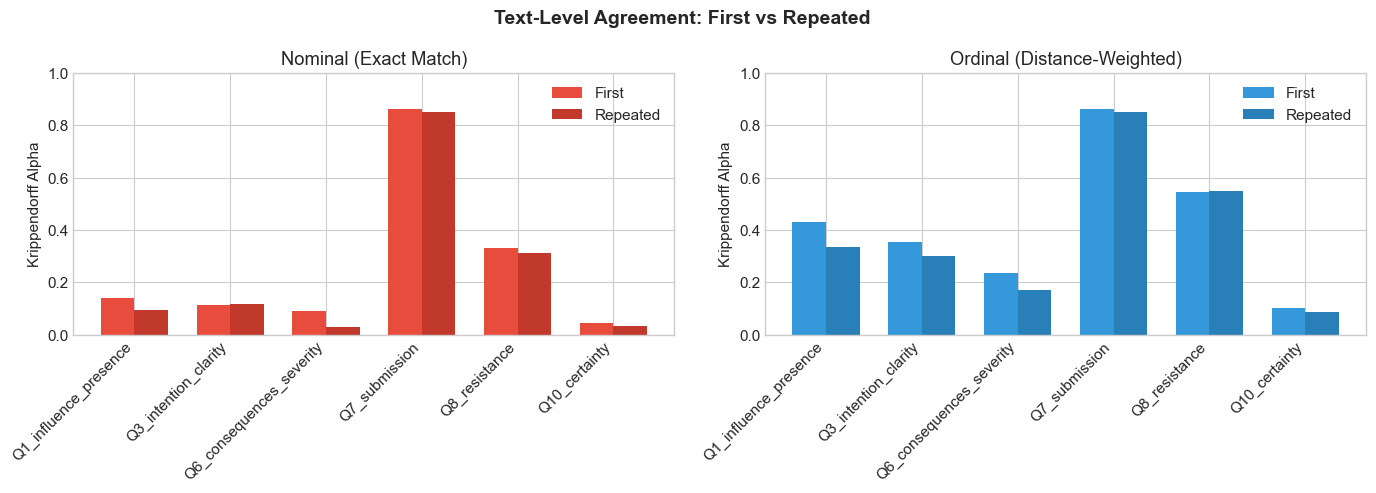

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

questions_short = [q.replace('question_', 'Q') for q in ORDINAL_MAPPINGS.keys()]
x = np.arange(len(questions_short))
width = 0.35

axes[0].bar(x - width/2, df_nominal['kripp_first'], width, label='First', color='#e74c3c')
axes[0].bar(x + width/2, df_nominal['kripp_repeated'], width, label='Repeated', color='#c0392b')
axes[0].set_ylabel('Krippendorff Alpha')
axes[0].set_title('Nominal (Exact Match)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(questions_short, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(x - width/2, df_ordinal['kripp_ord_first'], width, label='First', color='#3498db')
axes[1].bar(x + width/2, df_ordinal['kripp_ord_repeated'], width, label='Repeated', color='#2980b9')
axes[1].set_ylabel('Krippendorff Alpha')
axes[1].set_title('Ordinal (Distance-Weighted)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(questions_short, rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.suptitle('Text-Level Agreement: First vs Repeated', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Pairwise Agreement (Between Annotator Groups)
Cohen's Kappa between pairs of annotator groups on texts they both rated

In [163]:
def cohens_kappa_nominal(v1, v2):
    categories = list(set(v1.tolist() + v2.tolist()))
    n = len(v1)
    if n == 0:
        return np.nan
    po = (v1 == v2).sum() / n
    pe = sum((v1 == c).sum() * (v2 == c).sum() for c in categories) / (n * n)
    return (po - pe) / (1 - pe) if pe < 1 else 0

def weighted_kappa_quadratic(v1, v2, mapping):
    valid_mapping = {k: v for k, v in mapping.items() if not (isinstance(v, float) and np.isnan(v))}
    mask = v1.isin(valid_mapping.keys()) & v2.isin(valid_mapping.keys())
    if mask.sum() < 2:
        return np.nan
    
    v1_num = v1[mask].map(valid_mapping).values
    v2_num = v2[mask].map(valid_mapping).values
    n = len(v1_num)
    k = len(valid_mapping)
    
    max_dist = (k - 1) ** 2
    if max_dist == 0:
        return 1.0 if (v1_num == v2_num).all() else 0.0
    
    observed = np.sum((v1_num - v2_num) ** 2) / (n * max_dist)
    
    hist1 = np.bincount(v1_num.astype(int), minlength=k) / n
    hist2 = np.bincount(v2_num.astype(int), minlength=k) / n
    expected = sum(hist1[i] * hist2[j] * ((i - j) ** 2) for i in range(k) for j in range(k)) / max_dist
    
    return 1 - observed / expected if expected > 0 else 0

def pairwise_kappas_text_level(df, question, mapping):
    pivot = df.pivot_table(index='id', columns='annotator_group', values=question, aggfunc='first')
    groups = pivot.columns.tolist()
    results = []
    
    for g1, g2 in combinations(groups, 2):
        mask = pivot[g1].notna() & pivot[g2].notna()
        if mask.sum() < 2:
            continue
        v1, v2 = pivot.loc[mask, g1], pivot.loc[mask, g2]
        
        results.append({
            'group_1': g1, 'group_2': g2,
            'kappa_nominal': cohens_kappa_nominal(v1, v2),
            'kappa_weighted': weighted_kappa_quadratic(v1, v2, mapping),
            'n': mask.sum()
        })
    
    return pd.DataFrame(results)

In [164]:
pairwise_comparison = []
for question, mapping in ORDINAL_MAPPINGS.items():
    pw_first = pairwise_kappas_text_level(df_first, question, mapping)
    pw_repeated = pairwise_kappas_text_level(df_repeated, question, mapping)
    
    merged = pw_first.merge(pw_repeated, on=['group_1', 'group_2'], suffixes=('_first', '_repeated'))
    
    pairwise_comparison.append({
        'question': question.replace('question_', 'Q'),
        'nominal_first': merged['kappa_nominal_first'].mean(),
        'nominal_repeated': merged['kappa_nominal_repeated'].mean(),
        'weighted_first': merged['kappa_weighted_first'].mean(),
        'weighted_repeated': merged['kappa_weighted_repeated'].mean(),
        'n_pairs': len(merged)
    })

df_pairwise = pd.DataFrame(pairwise_comparison)
df_pairwise['nominal_change'] = df_pairwise['nominal_repeated'] - df_pairwise['nominal_first']
df_pairwise['weighted_change'] = df_pairwise['weighted_repeated'] - df_pairwise['weighted_first']
df_pairwise

,question,nominal_first,nominal_repeated,weighted_first,weighted_repeated,n_pairs,nominal_change,weighted_change
0,Q1_influence_presence,0.137263,0.104003,0.490318,0.455151,10,-0.033259,-0.035167
1,Q3_intention_clarity,0.117355,0.108222,0.388215,0.297582,10,-0.009132,-0.090633
2,Q6_consequences_severity,0.087284,0.038730,0.226480,0.181672,10,-0.048554,-0.044809
3,Q7_submission,0.600552,0.668819,0.906199,0.874423,10,0.068267,-0.031776
4,Q8_resistance,0.380753,0.394339,0.525746,0.529939,10,0.013586,0.004193
5,Q10_certainty,0.052398,0.049721,0.116461,0.107977,10,-0.002677,-0.008484


## Statistical Tests

In [165]:
stat_results = []
for question, mapping in ORDINAL_MAPPINGS.items():
    pw_first = pairwise_kappas_text_level(df_first, question, mapping)
    pw_repeated = pairwise_kappas_text_level(df_repeated, question, mapping)
    merged = pw_first.merge(pw_repeated, on=['group_1', 'group_2'], suffixes=('_first', '_repeated'))
    
    if len(merged) > 1:
        t_nom, p_nom = stats.ttest_rel(merged['kappa_nominal_first'], merged['kappa_nominal_repeated'])
        t_wgt, p_wgt = stats.ttest_rel(merged['kappa_weighted_first'], merged['kappa_weighted_repeated'])
    else:
        t_nom, p_nom, t_wgt, p_wgt = np.nan, np.nan, np.nan, np.nan
    
    stat_results.append({
        'question': question.replace('question_', 'Q'),
        't_nominal': t_nom, 'p_nominal': p_nom, 'sig_nominal': p_nom < 0.05 if not np.isnan(p_nom) else False,
        't_weighted': t_wgt, 'p_weighted': p_wgt, 'sig_weighted': p_wgt < 0.05 if not np.isnan(p_wgt) else False
    })

df_stats = pd.DataFrame(stat_results)
df_stats

,question,t_nominal,p_nominal,sig_nominal,t_weighted,p_weighted,sig_weighted
0,Q1_influence_presence,1.249891,0.242862,False,1.164374,0.274208,False
1,Q3_intention_clarity,0.539796,0.602436,False,4.088377,0.002724,True
2,Q6_consequences_severity,2.078079,0.067475,False,1.179683,0.268368,False
3,Q7_submission,-2.610764,0.028235,True,1.150248,0.279687,False
4,Q8_resistance,-0.442524,0.668554,False,-0.114657,0.911234,False
5,Q10_certainty,0.078917,0.938826,False,0.304235,0.767866,False


## Summary Visualizations

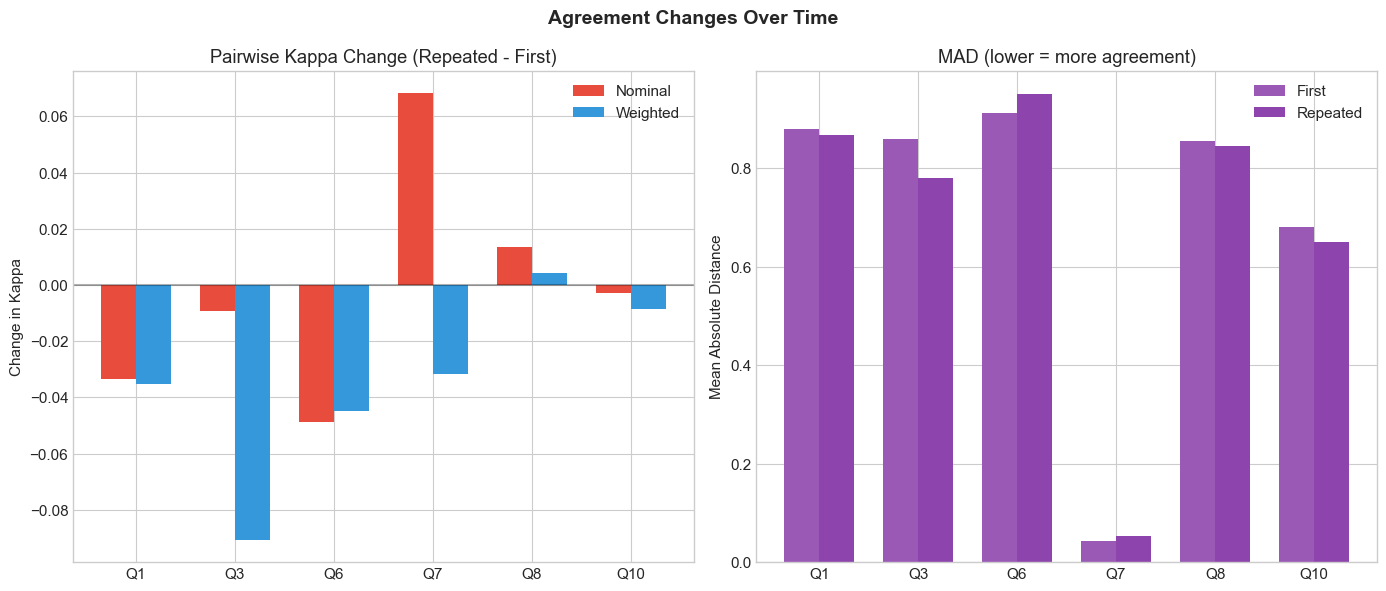

In [166]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

questions_short = ['Q1', 'Q3', 'Q6', 'Q7', 'Q8', 'Q10']
x = np.arange(len(questions_short))
width = 0.35

axes[0].bar(x - width/2, df_pairwise['nominal_change'], width, label='Nominal', color='#e74c3c')
axes[0].bar(x + width/2, df_pairwise['weighted_change'], width, label='Weighted', color='#3498db')
axes[0].set_ylabel('Change in Kappa')
axes[0].set_title('Pairwise Kappa Change (Repeated - First)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(questions_short)
axes[0].legend()
axes[0].axhline(y=0, color='black', linestyle='-', alpha=0.3)

axes[1].bar(x - width/2, df_ordinal['mad_first'], width, label='First', color='#9b59b6')
axes[1].bar(x + width/2, df_ordinal['mad_repeated'], width, label='Repeated', color='#8e44ad')
axes[1].set_ylabel('Mean Absolute Distance')
axes[1].set_title('MAD (lower = more agreement)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(questions_short)
axes[1].legend()

plt.suptitle('Agreement Changes Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()